# Week 1 — Run it, then discover a real truth yourself

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/00Bhuwan/flyrank-ml-internship-my-work/blob/main/notebooks/01_first_look_and_discovery.ipynb)

By the end of this notebook you will have:
1. **Run a real ML pipeline** on real (anonymized) search data and watched a learned model beat a hand-written rule.
2. **Rediscovered a real finding yourself** in ~10 lines of pandas.

No prior ML needed. Everything runs on the small anonymized dataset that ships with this repo — no credentials, no private data.

## 0. Setup (Colab or local)
On Colab this clones the repo and installs requirements. Locally it just moves to the repo root.

In [74]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")  # move from notebooks/ to the repo root

print("Working dir:", os.getcwd())
assert os.path.exists("data/raw/content_refresh_anonymized.csv"), "starter CSV not found — are you at the repo root?"
print("Starter data found. You're ready.")

Working dir: /content/flyrank-ml-internship-starter/flyrank-ml-internship-starter/flyrank-ml-internship-starter
Starter data found. You're ready.


## 1. Run the whole pipeline

This runs `scripts/run_all.py`: prepare features → baseline rule → train 3 models → evaluate → PDF.
It takes ~1 minute on the 30,000-row sample.

In [75]:
# Watch it work — each of the 5 steps prints live as it runs (~1 minute total).
!{sys.executable} scripts/run_all.py



▶ Step 1/5 — Prepare features — clean the data, build the feature vector, define the label
Prepared 30,000 rows from 30,000 raw rows
Wrote /content/flyrank-ml-internship-starter/flyrank-ml-internship-starter/flyrank-ml-internship-starter/data/processed/refresh_feature_vector.csv

▶ Step 2/5 — Baseline — a transparent hand-written rule to beat
Wrote baseline queue: /content/flyrank-ml-internship-starter/flyrank-ml-internship-starter/flyrank-ml-internship-starter/data/processed/baseline_refresh_queue.csv
Top-50 declining rate (full data, not the evaluated holdout Precision@50): 0.340

▶ Step 3/5 — Train — logistic regression, decision tree, random forest (client-holdout split)
Trained 3 models on 30,000 rows
Split strategy: client_holdout
Best model: random_forest
Wrote predictions: /content/flyrank-ml-internship-starter/flyrank-ml-internship-starter/flyrank-ml-internship-starter/data/processed/model_predictions.csv
Wrote model results: /content/flyrank-ml-internship-starter/flyrank-ml-

### What just happened?
The pipeline ranked every page for "refresh review" two ways: a **hand-written rule baseline** and a **learned model**. Let's compare them on **Precision@50** — of the top 50 pages each says to fix first, how many are actually declining?

In [76]:
import json
res = json.load(open("outputs/model_results.json"))

base = res["baseline"]["baseline_precision_at_50"]
rf   = res["models"]["random_forest"]["precision_at_50"]

print(f"Hand-written rule  Precision@50: {base:.3f}   (~{round(base*50)} of the top 50 right)")
print(f"Random forest      Precision@50: {rf:.3f}   (~{round(rf*50)} of the top 50 right)")
print(f"\nThe learned model roughly {rf/base:.1f}x the rule on this metric.")
print("Validation split used:", res["split_strategy"], "(pages from a client are never in both train and test)")

Hand-written rule  Precision@50: 0.240   (~12 of the top 50 right)
Random forest      Precision@50: 0.740   (~37 of the top 50 right)

The learned model roughly 3.1x the rule on this metric.
Validation split used: client_holdout (pages from a client are never in both train and test)


You just ran a real ML system on real search data and saw a learned ranking beat a fixed rule. Now open `outputs/model_report.md` and skim it — that Markdown report is the *shape* of what your own capstone should produce.

## 2. Discover a real truth yourself

The safest, most satisfying early wins are **things you find in the data** — un-leakable, and they *are* the core lesson. Run the three cells below. Each is ~10 lines of pandas and each overturns a common SEO belief.

Every number is **computed live from the shipped CSV** — nothing is hardcoded.

In [77]:
import pandas as pd, numpy as np
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
print(df.shape[0], "rows,", df.shape[1], "columns")
df.head(3)

30000 rows, 44 columns


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9


In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   content_id              30000 non-null  object 
 1   client_id               30000 non-null  object 
 2   search_volume           27532 non-null  float64
 3   competition             27532 non-null  float64
 4   competition_level       27390 non-null  object 
 5   cpc                     27532 non-null  float64
 6   content_type            30000 non-null  object 
 7   main_intent             27626 non-null  object 
 8   word_count              22301 non-null  float64
 9   char_count              22301 non-null  float64
 10  provider_used           8562 non-null   object 
 11  model_used              24267 non-null  object 
 12  impressions_90d         30000 non-null  int64  
 13  clicks_90d              30000 non-null  int64  
 14  pageviews_90d           30000 non-null

In [79]:
df.sample(5).T

,26594,1200,20879,20024,29993
content_id,content_b2639ec1c423,content_cd145ae2eb8c,content_9597d14e7fa8,content_04e4758a92b5,content_9bd30342fd4a
client_id,client_19581e27de,client_4e07408562,client_6208ef0f77,client_3fdba35f04,client_19581e27de
search_volume,0.0,590.0,0.0,0.0,70.0
competition,0.0,0.98,0.0,0.0,0.95
competition_level,LOW,HIGH,LOW,LOW,HIGH
cpc,0.0,0.8,0.0,0.0,0.34
content_type,keyword article,keyword article,keyword article,keyword article,keyword article
main_intent,informational,informational,informational,informational,transactional
word_count,NaN,3150.0,5687.0,2510.0,NaN
char_count,NaN,20992.0,36867.0,15239.0,NaN


### Discovery A — "High search volume means more traffic." Does it?

In [80]:
corr = df["search_volume"].corr(df["impressions_90d"])
print(f"Correlation between search_volume and impressions_90d: {corr:.3f}")
print("Near zero -> keyword search volume barely predicts the traffic a page actually gets.")

Correlation between search_volume and impressions_90d: 0.001
Near zero -> keyword search volume barely predicts the traffic a page actually gets.


### Discovery B — the CTR cliff by position
Click-through rate is not flat: it collapses as you move down the results.

In [81]:
print(visible.shape)
df["search_volume"].shape

(22006, 44)


(30000,)

position_tier
page_1      0.3548
top_3       0.3341
striking    0.2558
page_3_5    0.1424
deep        0.0554


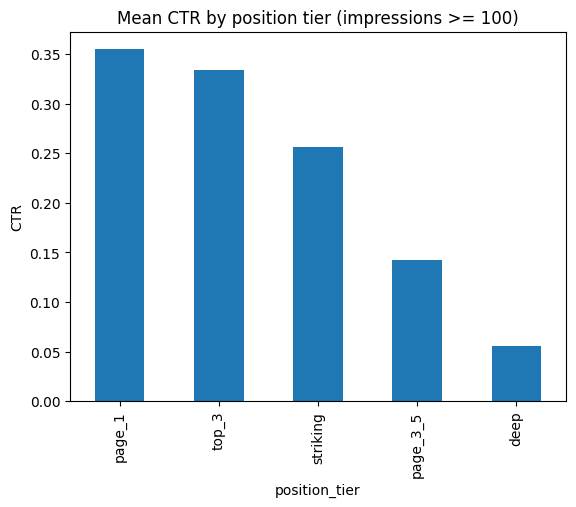

In [82]:
visible = df[df["impressions_90d"] >= 100]
ctr_by_pos = visible.groupby("position_tier")["ctr"].mean().sort_values(ascending=False)
print(ctr_by_pos.round(4).to_string())
ctr_by_pos.plot(kind="bar", title="Mean CTR by position tier (impressions >= 100)", ylabel="CTR");

### Discovery C — is longer content the lever?
Compare word count for **declining** vs **growing** pages.

In [83]:
wc = df.groupby("trend_direction")["word_count"].median()
print(wc.round(0).to_string())
print("\n'down' vs 'up' pages have almost the same median word count -> length is not the lever.")

trend_direction
down      2909.0
flat      2698.0
new       2239.0
stable    2912.0
up        2848.0

'down' vs 'up' pages have almost the same median word count -> length is not the lever.


## 3. 🔧 Your turn

Pick **one** of these and write a few lines below. This is your Week-1 discovery — you'll reference it in your Week-1 research-question write-up (on the InternHQ board).

- Redo Discovery A but only for pages with `impressions_90d > 0` — does the correlation change?
- In Discovery B, which `content_type` has the worst CTR *at the same position tier*?
- Find another belief to test: does `content_age_days` relate to `trend_direction`? Does `avg_position` relate to `ctr`?

**Rules:** describe what you observe as *observed / directional* — never "I proved Google's algorithm." Keep client data out of anything you publish.

# Discovery A for pages impression_90d > 0?

In [84]:
# Your discovery here
impress = df[df["impressions_90d"] > 0]
print(impress.shape)
print(df.shape)
print("it seems all the content have impression greater than 0 for 90 days interval. so, the correction will remain same for this.")
corr_impress = impress["search_volume"].corr(impress["impressions_90d"])
print(f"Correlation between search_volume and impressions_90d: {corr_impress:.3f}")
print("Near zero -> keyword search volume barely predicts the traffic a page actually gets.")

(30000, 44)
(30000, 44)
it seems all the content have impression greater than 0 for 90 days interval. so, the correction will remain same for this.
Correlation between search_volume and impressions_90d: 0.001
Near zero -> keyword search volume barely predicts the traffic a page actually gets.


#Discovery B, which content_type has the worst CTR at the same position tier?

Suppose, here also we are referring to data having impression for 90days greater than 100

In [85]:
visible = df[df["impressions_90d"] >= 100]
for i in df['content_type'].unique():
  print(f"Position tier {i}")
  ctr_by_content = visible[visible["content_type"] == i].groupby("position_tier")['ctr'].mean().sort_values(ascending=False)
  print(ctr_by_content.round(4).to_string())

Position tier keyword article
position_tier
page_1      0.3458
top_3       0.3104
striking    0.2559
page_3_5    0.1427
deep        0.0555
Position tier feedly article
position_tier
top_3       2.9000
page_1      0.9048
striking    0.3580
page_3_5    0.1656
deep        0.0440
Position tier comparison article
position_tier
striking    0.1474
page_1      0.1412
page_3_5    0.0940
top_3       0.0000


From the above result we can clearly see that the comparision article seem to worst type of content that has veryless amount of ctr value followed by feedly article and keyword seem to rank high.

# Find another belief to test: does content_age_days relate to trend_direction? Does avg_position relate to ctr?

In [86]:
c_age_relate = df[["content_age_days", "trend_direction"]]
c_age_relate.groupby("trend_direction")["content_age_days"].mean().sort_values(ascending=False)

,content_age_days
trend_direction,
stable,295.439953
up,288.478806
flat,245.889757
new,238.718247
down,236.178637


Text(0, 0.5, 'Content age')

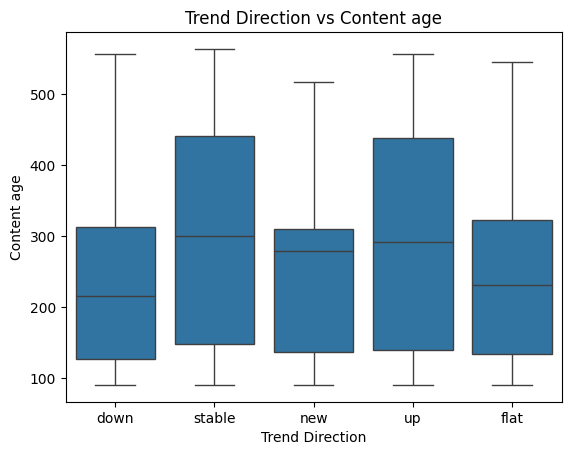

In [87]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='trend_direction', y='content_age_days', data=df)
plt.title('Trend Direction vs Content age')
plt.xlabel('Trend Direction')
plt.ylabel('Content age')

There doesn't seem to strong relation between content age with respect ot its trend.

In [88]:
df[['avg_position', 'ctr']].corr()

,avg_position,ctr
avg_position,1.00000,-0.07259
ctr,-0.07259,1.00000


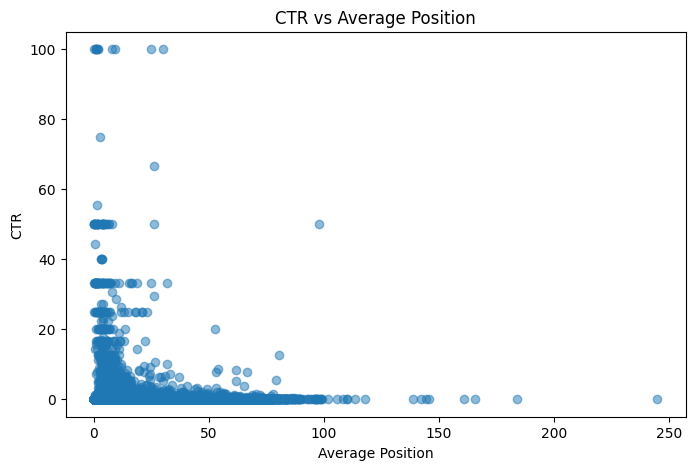

In [89]:
plt.figure(figsize=(8,5))
plt.scatter(df["avg_position"], df["ctr"], alpha=0.5)
plt.xlabel("Average Position")
plt.ylabel("CTR")
plt.title("CTR vs Average Position")
plt.show()

In [90]:
bins = [0, 3, 10, 20, 50, 100]
labels = ["Top 3", "4-10", "11-20", "21-50", "50+"]

df["position_group"] = pd.cut(
    df["avg_position"],
    bins=bins,
    labels=labels
)

df.groupby("position_group", observed=True)["ctr"].mean()

,ctr
position_group,
Top 3,2.714303
4-10,0.651045
11-20,0.323443
21-50,0.222345
50+,0.152525


We can see that the mean value highest correspond to top 3 of in position ranking. The decrease in ctr implies decrease in position ranking. so, yes the avg_position is directly related with the ctr value.

### Save your work
**Colab:** *File → Save a copy in GitHub* (writes to your own repo — that's your submission) and *File → Save a copy in Drive* (so the session doesn't evaporate).

Next: `02_your_first_readable_model.ipynb` — where the model becomes a rule you can read.